# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [7]:
df = pd.read_csv('dados_processados_M21.csv')

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [8]:
print(df.columns.tolist())

['Age', 'Income', 'Number of Children', 'Credit Score', 'Gender_Female', 'Gender_Male', "Education_Associate's Degree", "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Married', 'Marital Status_Single', 'Home Ownership_Owned', 'Home Ownership_Rented']


In [9]:
# Definindo o nome exato da coluna alvo
target_col = 'Credit Score'

# Separação das explicativas (X) e alvo (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Divisão entre treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [10]:
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:   {y_test.shape}\n")

X_train: (114, 14)
y_train: (114,)
X_test:  (50, 14)
y_test:   (50,)



In [11]:
print("Contagem por classe:")
print(y_test.value_counts())

print("\nProporção relativa (%):")
print(y_test.value_counts(normalize=True) * 100)

Contagem por classe:
Credit Score
3.0    34
2.0    11
1.0     5
Name: count, dtype: int64

Proporção relativa (%):
Credit Score
3.0    68.0
2.0    22.0
1.0    10.0
Name: proportion, dtype: float64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

In [ ]:
# Preparar os dados: Separar as variáveis de entrada
# e a variável que queremos prever, e dividir a base em Treino e Teste.
# Treinar o modelo para a árvore aprender as regras de decisão baseadas nos dados.
# Fazer previsões para gerar os palpites do modelo nos dados de teste.
# Avaliar os resultados, conferir os acertos usando métricas como Acurácia, Matriz de Confusão, Precisão, Recall e F1-score.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [12]:
clf = DecisionTreeClassifier(criterion='gini', random_state=0)

clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)

acc_train = accuracy_score(y_train, y_pred_train)
print(f"Acurácia nos dados de treino: {acc_train:.4f}")

Acurácia nos dados de treino: 1.0000


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [13]:
y_pred_test = clf.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia nos dados de treino: {acc_train:.4f}")
print(f"Acurácia nos dados de teste:  {acc_test:.4f}\n")

print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred_test))

print("\n Relatório de Classificação")
print(classification_report(y_test, y_pred_test))

Acurácia nos dados de treino: 1.0000
Acurácia nos dados de teste:  0.9400

Matriz de Confusão
[[ 5  0  0]
 [ 1  9  1]
 [ 0  1 33]]

 Relatório de Classificação
              precision    recall  f1-score   support

         1.0       0.83      1.00      0.91         5
         2.0       0.90      0.82      0.86        11
         3.0       0.97      0.97      0.97        34

    accuracy                           0.94        50
   macro avg       0.90      0.93      0.91        50
weighted avg       0.94      0.94      0.94        50



In [ ]:
# O modelo apresentou um ótimo desempenho geral no teste,
# mas pode ser aprimorado ajustando hiperparâmetros como a profundidade máxima da árvore (max_depth) 
# para evitar o superajuste no treino e tornar o modelo mais enxuto.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

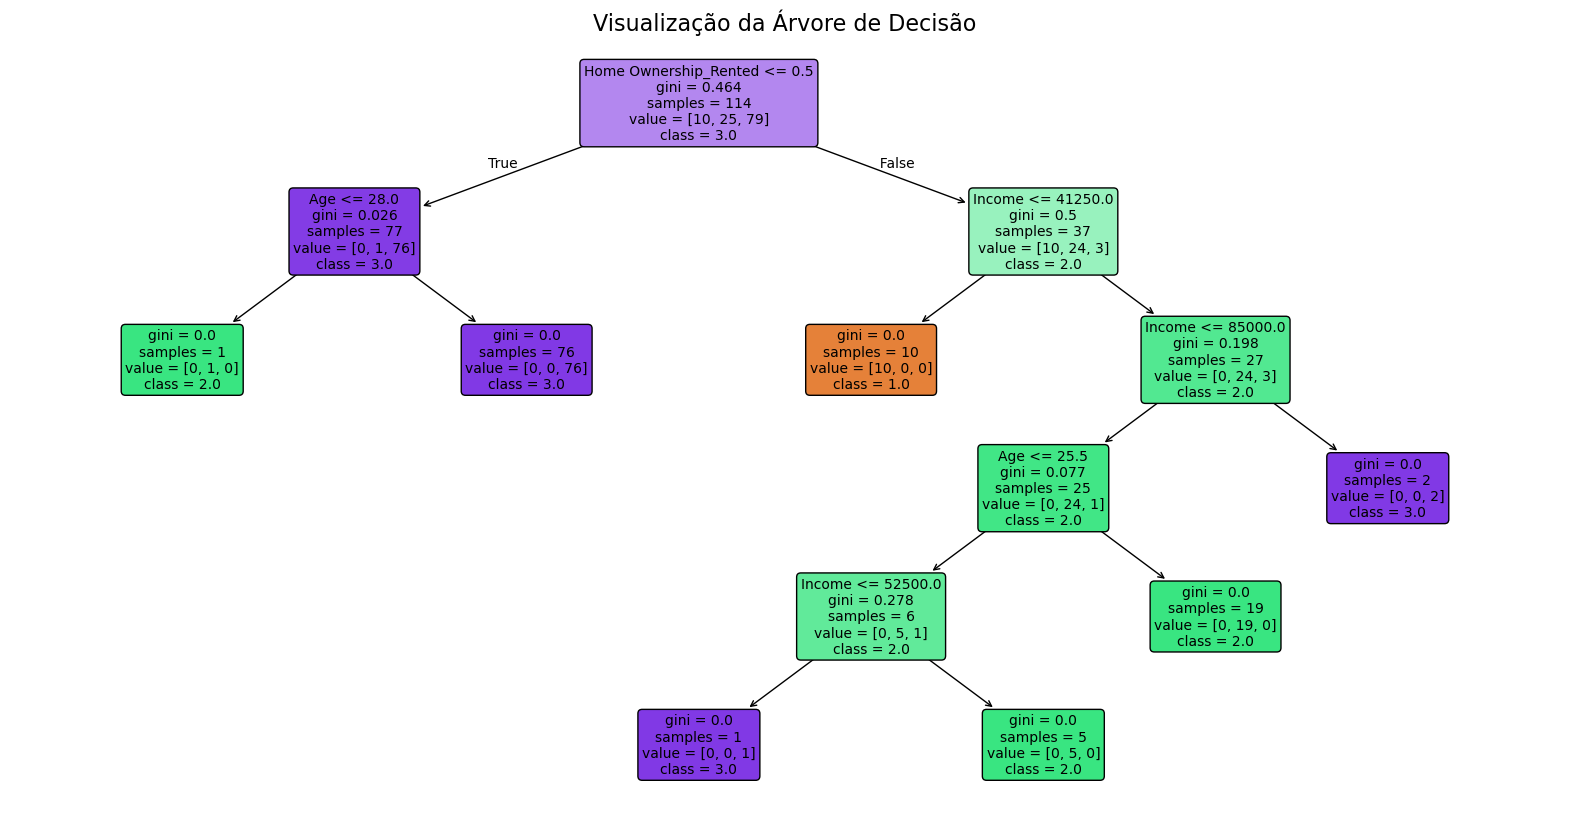

In [14]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=['1.0', '2.0', '3.0'],  # Ou [str(c) for c in clf.classes_]
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Visualização da Árvore de Decisão", fontsize=16)
plt.show()

In [ ]:
# A árvore possui uma estrutura relativamente pequena e limpa,
# permitindo visualizar claramente cada nó,
# as regras de divisão (como Home Ownership_Rented <= 0.5, Age <= 28.0 e Income <= 41250.0),
# a contagem de amostras (samples), o índice de Gini e a classe final definida em cada folha.

In [ ]:
# A profundidade da árvore é 5 (contando o nó raiz na camada 0 até o nível mais profundo das folhas).

# 6) Identifique as 2 principais features do modelo.


In [17]:
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': clf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

In [20]:
print("As 2 principais features:")
print(importancias.head(2))

As 2 principais features:
                  Feature  Importancia
13  Home Ownership_Rented     0.613184
1                  Income     0.344706


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [21]:
features_principais = ['Home Ownership_Rented', 'Income']

X_train_sub = X_train[features_principais]
X_test_sub = X_test[features_principais]

# 2. Instanciar e treinar o novo modelo
clf_sub = DecisionTreeClassifier(criterion='gini', random_state=0)
clf_sub.fit(X_train_sub, y_train)

# previsões
y_pred_train_sub = clf_sub.predict(X_train_sub)
y_pred_test_sub = clf_sub.predict(X_test_sub)

# 4. Avaliação
acc_train_sub = accuracy_score(y_train, y_pred_train_sub)
acc_test_sub = accuracy_score(y_test, y_pred_test_sub)

print(f"Nova Acurácia no Treino: {acc_train_sub:.4f}")
print(f"Nova Acurácia no Teste:  {acc_test_sub:.4f}\n")

print("Matriz de Confusão (Teste)")
print(confusion_matrix(y_test, y_pred_test_sub))

print("\n Relatório de Classificação (Teste)")
print(classification_report(y_test, y_pred_test_sub))

Nova Acurácia no Treino: 0.9912
Nova Acurácia no Teste:  0.9400

Matriz de Confusão (Teste)
[[ 5  0  0]
 [ 1  9  1]
 [ 0  1 33]]

 Relatório de Classificação (Teste)
              precision    recall  f1-score   support

         1.0       0.83      1.00      0.91         5
         2.0       0.90      0.82      0.86        11
         3.0       0.97      0.97      0.97        34

    accuracy                           0.94        50
   macro avg       0.90      0.93      0.91        50
weighted avg       0.94      0.94      0.94        50



In [ ]:
# O modelo com apenas 2 variáveis é superior (melhor) ao modelo anterior.

In [ ]:
# A acurácia no teste permaneceu exatamente a mesma (94%), mantendo os mesmos índices de Precisão, Recall e F1-score para todas as classes.
# A acurácia no treino caiu ligeiramente de 100% para 99,12%, o que demonstra que o modelo ficou um pouco menos "decorado" e mais generalista.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [ ]:
# O Naïve Bayes conseguiu capturar melhor as probabilidades gerais
# da base de teste sem sofrer com o overfitting que afetou a Árvore de Decisão no treino.
# Embora o Naïve Bayes tenha vencido em desempenho puro (98% vs 94%), a Árvore de Decisão ainda oferece a vantagem de ser um modelo
# cujas regras de decisão e variáveis mais importantes e
# são fáceis de explicar para regras de negócio e concessão de crédito.